# 控制流
- 顺序结构
- 分支结构

## 顺序结构
### add_edge()
### START、END节点
- END节点可以省略
### add_sequence()
- 入参为一个可执行对象列表，自动编排节点顺序，省去`add_node()`和`add_edge()操作`
- 示例：
    - `add_sequence([node1, node2])`
        -  其中node1和node2为函数，这里作为2个节点，节点名默认为函数名
        - 等价于:
            ```python
                    builder.add_node("node_a", node_a)
                    builder.add_node("node_b", node_b)
                    builder.add_edge("node_a", "node_b")
            ```

## 分支结构
- 静态分支: 下游候选节点在编译器完全确定
    - 并行节点
    - 条件分支
        - `add_conditional_edges()`

### 条件分支
- add_condiotnal_edges() 源码
    - ```python
        def add_conditional_edges(
            self,
            source: str,
            path: Callable[..., Hashable | Sequence[Hashable]]
            | Callable[..., Awaitable[Hashable | Sequence[Hashable]]]
            | Runnable[Any, Hashable | Sequence[Hashable]],
            path_map: dict[Hashable, str] | list[str] | None = None,
        ) -> Self:
      ```
        - source: 源节点
        - path: 路由规则，返回节点名称或tag名称
        - path_map: tag和node的映射。在某些情况下，path_map还可以辅助渲染流程图，在`条件条件单个节点`案例中，如果没有path_map,条件边并不知道下一个节点是什么，所以`node1`和`node2`会游离在图外。
        - 如果path_map为None，path必须返回节点名称，如果path_map定义了tag和映射，可以返回tag
        - tag可以描述业务，而节点名仍然可以保持工程化命名，便于维护和理解

#### 条件跳转单个节点

{'topic': '布偶狗', 'type': '诗', 'joke_res': AIMessage(content='为您创作了一首关于“布偶狗”的七言绝句。这首诗既描绘了毛发蓬松、长相甜美如玩偶的狗狗（如比熊、博美等），也契合了毛绒玩具狗的温馨意象：\n\n**《咏布偶狗》**\n\n**绒毛细软若云霜，**\n**乌瞳水润透灵光。**\n**欢摇短尾如布偶，**\n**伴主晨昏岁月长。**\n\n**【诗意赏析】**\n* **第一句**：描写“布偶狗”的外貌，毛发蓬松柔软，像云朵和霜雪一样洁白美丽，触感极佳。\n* **第二句**：聚焦它的面部神态，黑亮水润的眼睛里透着灵动与可爱，仿佛会说话一般。\n* **第三句**：点出“狗”的典型特征（摇尾巴），同时巧妙扣题“布偶”，形容它开心时摇着尾巴，像布偶一样憨态可掬、惹人怜爱。\n* **第四句**：升华情感，写它忠诚地陪伴在主人身边，从早到晚，在悠长的岁月里带来无尽的温暖与慰藉。\n\n*(注：如果您所说的“布偶狗”是指宠物界毛发甜美的狗狗，或是陪伴孩子的毛绒玩具狗，此诗都非常契合。若是“布偶猫”的笔误，只需将第三句的“短尾”改为“长尾”或“细尾”即可。)*', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 3985, 'prompt_tokens': 22, 'total_tokens': 4007, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 3675, 'rejected_prediction_tokens': None, 'text_tokens': 3985}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 22}}, 'model_provider': 'openai', 'model_name': 'qwen3.7-plus', 'system_fingerprint'

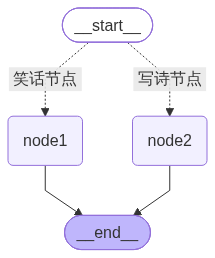

In [6]:
from IPython.core.display import display_png, Image
from langchain_core.messages import HumanMessage
from typing import TypedDict, Literal
from langgraph.constants import START, END
from langgraph.graph import StateGraph

from common import init_simple_dashscope_model

model = init_simple_dashscope_model('qwen3.7-plus')


class StateSchema(TypedDict):
    topic: str
    type: str
    poem_res: str
    joke_res: str


def node1(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的笑话")
    ])
    return {
        "poem_res": resp
    }


def node2(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的七言诗")
    ])
    return {
        "joke_res": resp
    }

# router 返回 tag，不是节点名
def router(state: StateSchema) -> Literal['写诗节点', '笑话节点']:
    if '诗' in state['type']:
        return "写诗节点"
    else:
        return "笑话节点"

# tag → 节点名 的映射
path_map = {
    "写诗节点": "node2",
    "笑话节点": "node1"
}

state_graph = StateGraph(state_schema=StateSchema)
state_graph.add_node("node1", node1)
state_graph.add_node("node2", node2)
state_graph.add_conditional_edges(START, router, path_map)
state_graph.add_edge('node1', END)
state_graph.add_edge('node2', END)

graph = state_graph.compile()
poem = graph.invoke(
    {
        "topic": "布偶狗",
        "type": "诗"
    }
)
print(poem)
#
# joke = graph.invoke(
#     {
#         "topic": "布偶狗",
#         "type": "笑话"
#     }
# )
# print(joke)

display_png(Image(graph.get_graph().draw_mermaid_png()))

#### 条件跳转多个节点
- 条件边的`router`函数可以返回序列

{'topic': '功夫猫', 'type': '诗', 'joke_res': AIMessage(content='为您创作了两首不同风格的关于“功夫猫”的七言绝句，一首侧重**武侠宗师风范**，另一首侧重**灵动俏皮的反差萌**，供您选择：\n\n### 其一：武侠宗师风（侧重意境与气场）\n**狸奴隐迹翠微中，**\n**纵跃飞檐气若虹。**\n**铁爪凌空惊百兽，**\n**江湖独步傲群雄。**\n\n* **赏析**：“狸奴”是古人对猫的雅称。这首诗将猫咪隐于竹林翠微之中，展现其深藏不露的高手气质。后两句描写它施展轻功飞檐走壁，铁爪挥出时气势如虹，连百兽为之震惊，点出它“独步江湖”的武林宗师地位。\n\n---\n\n### 其二：灵动俏皮风（侧重体态与反差萌）\n**绒爪轻舒步点霜，**\n**飞身倒挂探檐廊。**\n**莫看娇躯才数尺，**\n**降龙伏虎自称王。**\n\n* **赏析**：这首诗更突出“猫”本身的可爱特性与“功夫”的结合。前两句描写它毛茸茸的爪子轻点寒霜，还能像武林高手一样飞身倒挂在屋檐之下。后两句笔锋一转，带着几分俏皮与傲气：别看它身躯娇小只有几尺长，却有着降龙伏虎的绝世武功，自封为林间大王。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 3574, 'prompt_tokens': 21, 'total_tokens': 3595, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 3256, 'rejected_prediction_tokens': None, 'text_tokens': 3574}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 21}}, 'model_provider': 'openai', 'model_name': 'qwen3.7-plus', 'system_fing

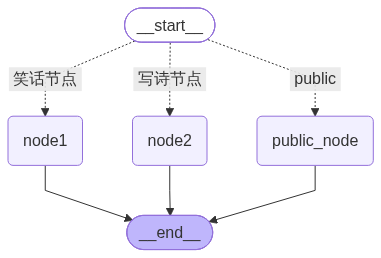

In [7]:
from IPython.core.display import display_png, Image
from langchain_core.messages import HumanMessage
from typing import TypedDict, Literal, Sequence
from langgraph.constants import START, END
from langgraph.graph import StateGraph

from common import init_simple_dashscope_model

model = init_simple_dashscope_model('qwen3.7-plus')


class StateSchema(TypedDict):
    topic: str
    type: str
    poem_res: str
    joke_res: str
    public_res: str


def public_node(state: StateSchema) -> StateSchema:
    return {
        "public_res": "This is a public response"
    }

def node1(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的笑话")
    ])
    return {
        "poem_res": resp
    }


def node2(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的七言诗")
    ])
    return {
        "joke_res": resp
    }

# router 返回 tag，不是节点名
def router(state: StateSchema) -> Sequence[Literal['写诗节点', '笑话节点', 'public']]:
    if '诗' in state['type']:
        return ["写诗节点", 'public']
    else:
        return ["笑话节点", 'public']

# tag → 节点名 的映射
path_map = {
    "写诗节点": "node2",
    "笑话节点": "node1",
    "public": "public_node"
}

state_graph = StateGraph(state_schema=StateSchema)
state_graph.add_node("node1", node1)
state_graph.add_node("node2", node2)
state_graph.add_node("public_node", public_node)
state_graph.add_conditional_edges(START, router, path_map)
state_graph.add_edge('node1', END)
state_graph.add_edge('public_node', END)
state_graph.add_edge('node2', END)

graph = state_graph.compile()
poem = graph.invoke(
    {
        "topic": "功夫猫",
        "type": "诗"
    }
)
print(poem)
#
# joke = graph.invoke(
#     {
#         "topic": "布偶狗",
#         "type": "笑话"
#     }
# )
# print(joke)

display_png(Image(graph.get_graph().draw_mermaid_png()))